In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Style for attractive visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


# STEP 1: PARSE AND CLEAN TRAFFIC / LOG DATA
print("--- Step 1: Loading and Cleaning Data ---")


df = pd.read_csv('traffic.csv')

# Injecting missing/null values and formatting issues for cleaning practice
df.loc[df.sample(frac=0.02).index, 'linkid'] = np.nan

# 1.1 Handle missing values
df['linkid'] = df['linkid'].fillna('Unknown/Direct')

# 1.2 Parse datetime features
df['date'] = pd.to_datetime(df['date'])

print(f"Data Cleaned successfully. Total Rows: {len(df)}")
print(df.head(), "\n")



--- Step 1: Loading and Cleaning Data ---
Data Cleaned successfully. Total Rows: 226278
   event       date       country      city  \
0  click 2021-08-21  Saudi Arabia    Jeddah   
1  click 2021-08-21  Saudi Arabia    Jeddah   
2  click 2021-08-21         India  Ludhiana   
3  click 2021-08-21        France   Unknown   
4  click 2021-08-21      Maldives      Malé   

                              artist          album          track  \
0                             Tesher    Jalebi Baby    Jalebi Baby   
1                             Tesher    Jalebi Baby    Jalebi Baby   
2                      Reyanna Maria      So Pretty      So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores Más  No Llores Más   
4                             Tesher    Jalebi Baby    Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
2  USUM72100871  23199824-9cf5-4b98-942a

In [13]:
# 1. Total Unique Users
total_users = df['linkid'].nunique()

# 2. Total Sessions 
session_counts = df.groupby(['linkid', 'date']).size().reset_index(name='tracks_played')
total_sessions = len(session_counts)

# 3. Bounce Rate (Sessions where the user listened to exactly 1 track)
bounced_sessions = session_counts[session_counts['tracks_played'] == 1]
num_bounces = len(bounced_sessions)
bounce_rate = (num_bounces / total_sessions) * 100

# 4. Average Tracks Played per Session (Proxy for Session Duration/Engagement)
avg_tracks_per_session = session_counts['tracks_played'].mean()

# Display Metrics Summary
print("--- CORE TRAFFIC METRICS ---")
print(f"Total Unique Users:     {total_users:,}")
print(f"Total Sessions:         {total_sessions:,}")
print(f"Bounced Sessions:       {num_bounces:,}")
print(f"Platform Bounce Rate:   {bounce_rate:.2f}%")
print(f"Avg Tracks per Session: {avg_tracks_per_session:.2f}")

--- CORE TRAFFIC METRICS ---
Total Unique Users:     3,815
Total Sessions:         6,538
Bounced Sessions:       1,851
Platform Bounce Rate:   28.31%
Avg Tracks per Session: 34.61


In [14]:
# sorting 
df = df.sort_values(by=['linkid', 'date'])

# Identify Entry (Landing) track and Exit track for each session
# Since exact timestamps aren't present, the first/last appearing records per group are used
session_entries = df.groupby(['linkid', 'date']).first().reset_index()
session_exits = df.groupby(['linkid', 'date']).last().reset_index()

# Top 10 Entry Tracks
top_entries = session_entries['track'].value_counts().head(10)
print("\n--- TOP 10 LANDING (ENTRY) TRACKS ---")
print(top_entries)

# Top 10 Exit Tracks
top_exits = session_exits['track'].value_counts().head(10)
print("\n--- TOP 10 EXIT TRACKS ---")
print(top_exits)


--- TOP 10 LANDING (ENTRY) TRACKS ---
track
Beautiful                               17
traitor                                 16
Better Days                             16
happier                                 15
worldstar money (interlude)             14
ily (i love you baby) (feat. Emilee)    14
Among Us - Trap Remix                   14
Hindi                                   13
Up                                      13
So Pretty                               13
Name: count, dtype: int64

--- TOP 10 EXIT TRACKS ---
track
Beautiful                               18
traitor                                 16
Better Days                             16
ily (i love you baby) (feat. Emilee)    15
happier                                 15
Among Us - Trap Remix                   14
worldstar money (interlude)             14
Up                                      13
Hindi                                   13
So Pretty                               13
Name: count, dtype: int64


C:\Users\vaibh\AppData\Local\Temp\ipykernel_16428\3202333984.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_entries.values, y=top_entries.index, palette="viridis")
C:\Users\vaibh\AppData\Local\Temp\ipykernel_16428\3202333984.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_exits.values, y=top_exits.index, palette="magma")
C:\Users\vaibh\AppData\Local\Temp\ipykernel_16428\3202333984.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")



 ---Top 10 countries---
country
Saudi Arabia            47334
India                   42992
United States           32558
France                  15661
Iraq                     8260
United Kingdom           5970
Pakistan                 5644
Germany                  4794
United Arab Emirates     3702
Turkey                   3514
Name: count, dtype: int64


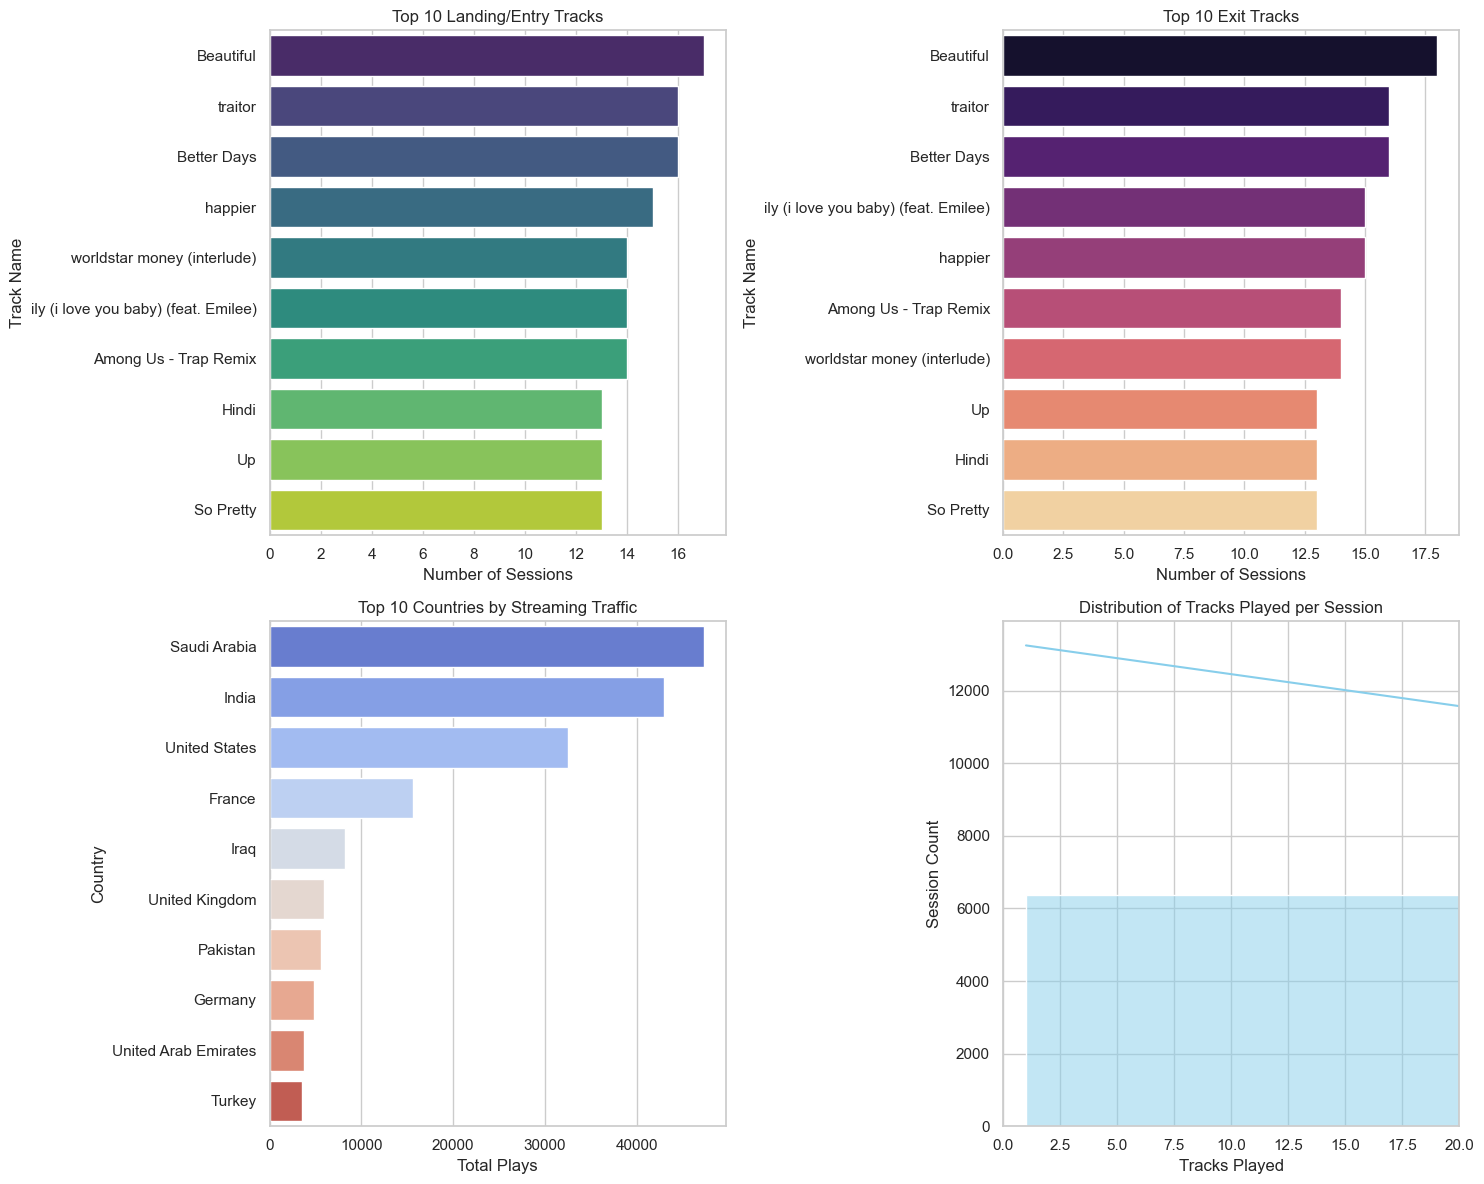

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# Plot 1: Top 10 Entry Tracks
plt.subplot(2, 2, 1)
sns.barplot(x=top_entries.values, y=top_entries.index, palette="viridis")
plt.title("Top 10 Landing/Entry Tracks")
plt.xlabel("Number of Sessions")
plt.ylabel("Track Name")

# Plot 2: Top 10 Exit Tracks
plt.subplot(2, 2, 2)
sns.barplot(x=top_exits.values, y=top_exits.index, palette="magma")
plt.title("Top 10 Exit Tracks")
plt.xlabel("Number of Sessions")
plt.ylabel("Track Name")

# Plot 3: Geographic Distribution (Top 10 Countries)
top_countries = df['country'].value_counts().head(10)
plt.subplot(2, 2, 3)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")
plt.title("Top 10 Countries by Streaming Traffic")
plt.xlabel("Total Plays")
plt.ylabel("Country")
print("\n ---Top 10 countries---")  
print(top_countries)

# Plot 4: Distribution of Tracks Played per Session
plt.subplot(2, 2, 4)
sns.histplot(session_counts['tracks_played'], bins=30, kde=True, color="skyblue")
plt.xlim(0, 20) # Focusing on the core distribution
plt.title("Distribution of Tracks Played per Session")
plt.xlabel("Tracks Played")
plt.ylabel("Session Count")

plt.tight_layout()
plt.savefig('traffic_analysis_dashboard.png', dpi=300)
plt.show()

In [25]:
# Calculate bounce rate per artist
# Find tracks that resulted in a bounce
bounced_user_dates = bounced_sessions[['linkid', 'date']]
bounced_tracks = pd.merge(df, bounced_user_dates, on=['linkid', 'date'])

# Artist popularity vs. Artist bounce contribution
top_artists = df['artist'].value_counts().head(10)
bounced_artists = bounced_tracks['artist'].value_counts().head(10)

print("\n--- TOP 5 MOST POPULAR ARTISTS ---")
print(top_artists.head(5))

print("\n--- TOP 5 ARTISTS WITH SINGLE-STREAM EXIT (BOUNCE) ---")
print(bounced_artists.head(5))


--- TOP 5 MOST POPULAR ARTISTS ---
artist
Tesher                                                          40841
Anne-Marie                                                      10650
Tundra Beats                                                     9751
Surf Mesa, Emilee                                                7533
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna     5512
Name: count, dtype: int64

--- TOP 5 ARTISTS WITH SINGLE-STREAM EXIT (BOUNCE) ---
artist
YoungBoy Never Broke Again    19
Lil Baby                      18
Various Artists               17
Lil Durk                      14
Gunna                         13
Name: count, dtype: int64
